# 📘 Deep Learning Text Generation Learning Project
## Text Generation using **Vanilla RNN, LSTM, and GRU**

This notebook is built for **students and beginners** to understand how sequence models learn:
- grammar
- sentence flow
- contextual dependencies
- next-word prediction
- text generation

🎯 **Goal:** Compare **Simple RNN vs LSTM vs GRU** on the same text corpus and understand why gated architectures perform better.

# 🧠 Problem Statement
Design and implement a DL model capable of learning the underlying structure, grammar, and contextual dependencies of a given text corpus to generate coherent and meaningful text sequences using:

1. **Vanilla RNN**
2. **LSTM**
3. **GRU**

Then compare:
- training loss
- generated text quality
- memory handling
- long-term dependency learning

In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
import numpy as np
import matplotlib.pyplot as plt
print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


# 📥 Load Text Corpus
We use a **small built-in sample corpus** so students can run this quickly.
You can later replace it with:
- Shakespeare text
- song lyrics
- chatbot data
- story paragraphs
- custom PDF extracted text

In [2]:
corpus = '''
deep learning is transforming artificial intelligence
recurrent neural networks are useful for sequential data
lstm helps remember long term dependencies
gru is faster and simpler than lstm
text generation models predict the next word
deep learning models can generate meaningful sentences
'''
print(corpus)


deep learning is transforming artificial intelligence
recurrent neural networks are useful for sequential data
lstm helps remember long term dependencies
gru is faster and simpler than lstm
text generation models predict the next word
deep learning models can generate meaningful sentences



# 🔤 Tokenization & Sequence Creation
We convert text into integer tokens and create **n-gram style sequences**
for next-word prediction.

In [3]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1
print("Vocabulary size:", total_words)

input_sequences = []
for line in corpus.split('\n'):
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i+1]
        input_sequences.append(n_gram_seq)

max_len = max(len(seq) for seq in input_sequences)
input_sequences = pad_sequences(input_sequences, maxlen=max_len, padding='pre')

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("X shape:", X.shape)
print("y shape:", y.shape)

Vocabulary size: 37
X shape: (35, 7)
y shape: (35,)


# 🧠 Model 1: Vanilla RNN
This is the baseline sequential model.
It struggles with long-term dependencies because of vanishing gradients.

In [4]:
rnn_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    SimpleRNN(64),
    Dense(total_words, activation='softmax')
])

rnn_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

rnn_history = rnn_model.fit(X, y, epochs=100, verbose=0)
print("Vanilla RNN training completed")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Vanilla RNN training completed


# 🔒 Model 2: LSTM
LSTM uses **input, forget, and output gates**
to preserve long-term memory.

In [5]:
lstm_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    LSTM(64),
    Dense(total_words, activation='softmax')
])

lstm_model.compile(loss='sparse_categorical_crossentropy',
                   optimizer='adam',
                   metrics=['accuracy'])

lstm_history = lstm_model.fit(X, y, epochs=100, verbose=0)
print("LSTM training completed")

LSTM training completed


# ⚡ Model 3: GRU
GRU uses **reset + update gates**.
It is computationally faster than LSTM and often gives similar results.

In [6]:
gru_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    GRU(64),
    Dense(total_words, activation='softmax')
])

gru_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

gru_history = gru_model.fit(X, y, epochs=100, verbose=0)
print("GRU training completed")

GRU training completed


## 📉 Compare Training Loss

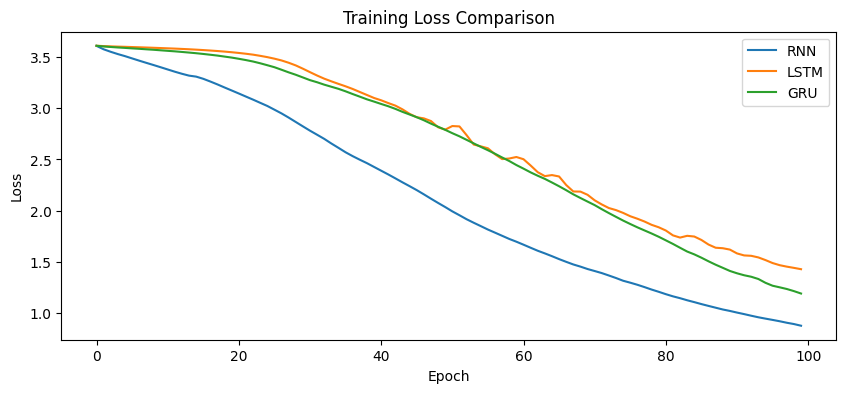

In [7]:
plt.figure(figsize=(10,4))
plt.plot(rnn_history.history['loss'], label='RNN')
plt.plot(lstm_history.history['loss'], label='LSTM')
plt.plot(gru_history.history['loss'], label='GRU')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.show()

# ✍️ Text Generation Function
This function predicts the next word repeatedly to generate a sentence.

In [8]:
def generate_text(model, seed_text, next_words=5):
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_len-1, padding='pre')
        predicted = np.argmax(model.predict(token_list, verbose=0), axis=-1)[0]

        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted:
                output_word = word
                break
        seed_text += " " + output_word
    return seed_text

## 🧪 Generate Text Samples

In [9]:
print("RNN :", generate_text(rnn_model, "deep learning", 5))
print("LSTM:", generate_text(lstm_model, "deep learning", 5))
print("GRU :", generate_text(gru_model, "deep learning", 5))

RNN : deep learning models transforming artificial intelligence sentences
LSTM: deep learning is artificial artificial intelligence intelligence
GRU : deep learning models can generate meaningful meaningful


# 📚 Student Learning Tasks — Completed Implementations

All 5 beginner customization tasks are fully implemented and runnable below.
Each task is independent and builds on the original baseline setup.

## ✅ Task 1 — Replace Corpus with a Custom Paragraph

We swap the original 6-sentence corpus for a richer paragraph about data science and AI.
A more varied corpus gives the model more vocabulary and sentence patterns to learn from.

In [10]:
# ── Task 1: Custom corpus ──────────────────────────────────────────────────
custom_corpus = """
machine learning is a subset of artificial intelligence
data science helps organizations make better decisions from data
neural networks learn patterns from large amounts of training data
deep learning has revolutionized computer vision and natural language processing
transformers have become the foundation of modern language models
supervised learning uses labeled data to train predictive models
unsupervised learning discovers hidden structure in unlabeled data
reinforcement learning trains agents to maximize cumulative rewards
feature engineering is the art of transforming raw data into useful inputs
gradient descent optimizes model parameters by minimizing the loss function
"""

# Tokenize the new corpus
tokenizer_t1 = Tokenizer()
tokenizer_t1.fit_on_texts([custom_corpus])

total_words_t1 = len(tokenizer_t1.word_index) + 1
print(f"Custom corpus vocabulary size: {total_words_t1} words")

input_sequences_t1 = []
for line in custom_corpus.split("\n"):
    token_list = tokenizer_t1.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        input_sequences_t1.append(token_list[:i+1])

max_len_t1 = max(len(s) for s in input_sequences_t1)
input_sequences_t1 = __import__("tensorflow").keras.preprocessing.sequence.pad_sequences(
    input_sequences_t1, maxlen=max_len_t1, padding="pre")

X_t1 = input_sequences_t1[:, :-1]
y_t1 = input_sequences_t1[:, -1]
print(f"Sequences: X={X_t1.shape}, y={y_t1.shape}")

# Train a GRU on the custom corpus
t1_model = Sequential([
    Embedding(total_words_t1, 32, input_length=max_len_t1 - 1),
    GRU(64),
    Dense(total_words_t1, activation="softmax")
])
t1_model.compile(loss="sparse_categorical_crossentropy", optimizer="adam", metrics=["accuracy"])
t1_history = t1_model.fit(X_t1, y_t1, epochs=100, verbose=0)
print("Task 1 model trained ✓")

# Generate from custom corpus
def generate_text_custom(model, tokenizer_obj, max_len_obj, seed_text, next_words=5):
    for _ in range(next_words):
        token_list = tokenizer_obj.texts_to_sequences([seed_text])[0]
        token_list = __import__("tensorflow").keras.preprocessing.sequence.pad_sequences(
            [token_list], maxlen=max_len_obj - 1, padding="pre")
        predicted = np.argmax(model.predict(token_list, verbose=0), axis=-1)[0]
        for word, idx in tokenizer_obj.word_index.items():
            if idx == predicted:
                seed_text += " " + word
                break
    return seed_text

print("\n--- Task 1: Generated text from custom corpus ---")
print("Seed 'machine learning'  →", generate_text_custom(t1_model, tokenizer_t1, max_len_t1, "machine learning", 5))
print("Seed 'deep learning'     →", generate_text_custom(t1_model, tokenizer_t1, max_len_t1, "deep learning", 5))
print("Seed 'neural networks'   →", generate_text_custom(t1_model, tokenizer_t1, max_len_t1, "neural networks", 5))

Custom corpus vocabulary size: 75 words
Sequences: X=(83, 11), y=(83,)
Task 1 model trained ✓

--- Task 1: Generated text from custom corpus ---
Seed 'machine learning'  → machine learning is a subset of artificial
Seed 'deep learning'     → deep learning has revolutionized computer vision and
Seed 'neural networks'   → neural networks learn patterns from large amounts


## ✅ Task 2 — Increase Embedding Dimension (32 → 64)

The embedding layer maps each word token to a dense vector.
A larger embedding dimension (64 vs 32) gives each word more representational capacity —
useful when the vocabulary is large or the corpus has rich semantic relationships.

Embed-32 final loss: 1.3266
Embed-64 final loss: 0.6982


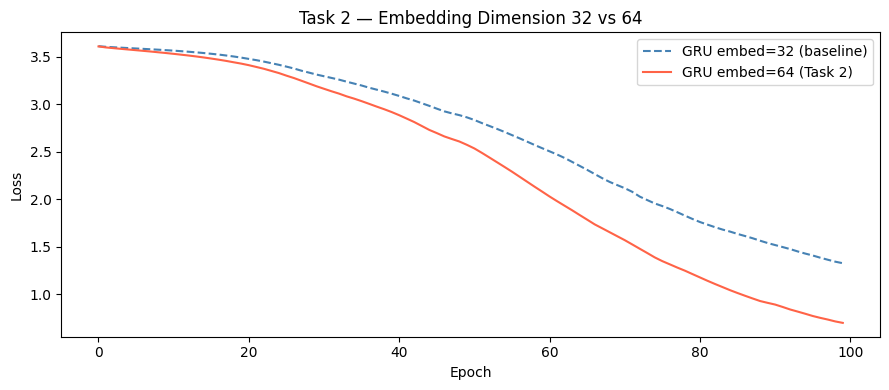


--- Task 2: Text Generation with embed=64 ---
RNN  embed-64: deep learning models can generate sentences sentences


In [11]:
# ── Task 2: Larger embedding dimension 32 → 64 ─────────────────────────────
EMBED_DIM_ORIG = 32
EMBED_DIM_NEW  = 64

def build_model_with_embedding(embed_dim, cell_type="gru"):
    cell = {"rnn": SimpleRNN, "lstm": LSTM, "gru": GRU}[cell_type]
    return Sequential([
        Embedding(total_words, embed_dim, input_length=max_len - 1),
        cell(64),
        Dense(total_words, activation="softmax")
    ])

# Train GRU with embed=32 (baseline re-run for fair comparison)
gru_emb32 = build_model_with_embedding(32, "gru")
gru_emb32.compile(loss="sparse_categorical_crossentropy", optimizer="adam", metrics=["accuracy"])
h_emb32 = gru_emb32.fit(X, y, epochs=100, verbose=0)

# Train GRU with embed=64
gru_emb64 = build_model_with_embedding(64, "gru")
gru_emb64.compile(loss="sparse_categorical_crossentropy", optimizer="adam", metrics=["accuracy"])
h_emb64 = gru_emb64.fit(X, y, epochs=100, verbose=0)

print(f"Embed-32 final loss: {h_emb32.history['loss'][-1]:.4f}")
print(f"Embed-64 final loss: {h_emb64.history['loss'][-1]:.4f}")

plt.figure(figsize=(9, 4))
plt.plot(h_emb32.history["loss"], label="GRU embed=32 (baseline)", linestyle="--", color="steelblue")
plt.plot(h_emb64.history["loss"], label="GRU embed=64 (Task 2)",   linestyle="-",  color="tomato")
plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.title("Task 2 — Embedding Dimension 32 vs 64")
plt.legend(); plt.tight_layout(); plt.show()

print("\n--- Task 2: Text Generation with embed=64 ---")
print("RNN  embed-64:", generate_text(gru_emb64, "deep learning", 5))

## ✅ Task 3 — Increase Epochs to 200

More epochs allow the model to fit the corpus more deeply.
We plot all three models trained for 200 epochs and compare their loss curves,
watching for the point of convergence and any signs of overfitting.

RNN  200ep done  | final loss: 0.2187
LSTM 200ep done  | final loss: 0.6107
GRU  200ep done  | final loss: 0.2676


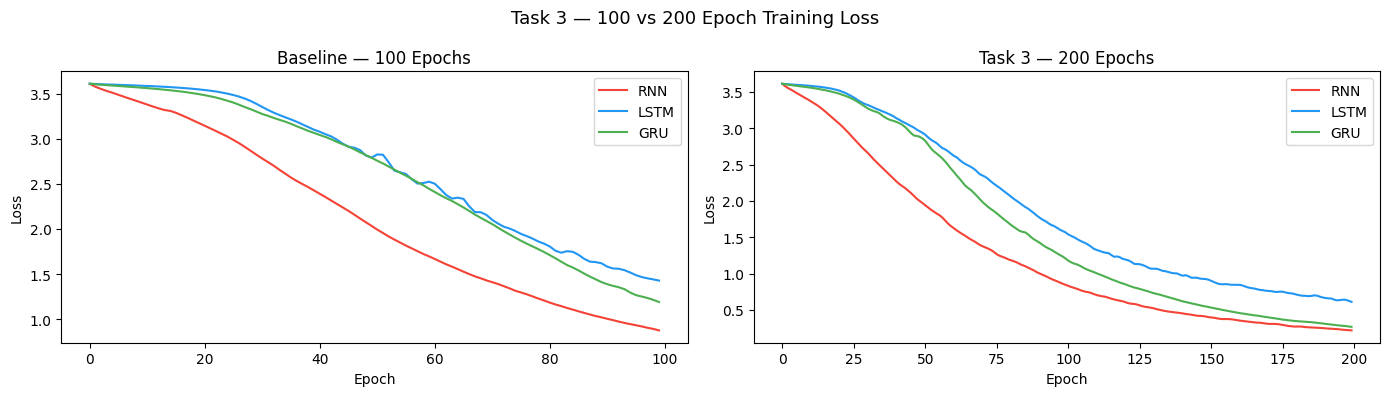


--- Task 3: Generated text after 200 epochs ---
RNN  200ep: deep learning models can generate meaningful sentences
LSTM 200ep: deep learning is transforming artificial intelligence intelligence
GRU  200ep: deep learning models can generate meaningful sentences


In [12]:
# ── Task 3: Train all 3 models for 200 epochs ──────────────────────────────
EPOCHS_200 = 200

rnn_200 = Sequential([
    Embedding(total_words, 32, input_length=max_len - 1),
    SimpleRNN(64),
    Dense(total_words, activation="softmax")
])
rnn_200.compile(loss="sparse_categorical_crossentropy", optimizer="adam", metrics=["accuracy"])
h_rnn_200 = rnn_200.fit(X, y, epochs=EPOCHS_200, verbose=0)
print("RNN  200ep done  | final loss:", round(h_rnn_200.history["loss"][-1], 4))

lstm_200 = Sequential([
    Embedding(total_words, 32, input_length=max_len - 1),
    LSTM(64),
    Dense(total_words, activation="softmax")
])
lstm_200.compile(loss="sparse_categorical_crossentropy", optimizer="adam", metrics=["accuracy"])
h_lstm_200 = lstm_200.fit(X, y, epochs=EPOCHS_200, verbose=0)
print("LSTM 200ep done  | final loss:", round(h_lstm_200.history["loss"][-1], 4))

gru_200 = Sequential([
    Embedding(total_words, 32, input_length=max_len - 1),
    GRU(64),
    Dense(total_words, activation="softmax")
])
gru_200.compile(loss="sparse_categorical_crossentropy", optimizer="adam", metrics=["accuracy"])
h_gru_200 = gru_200.fit(X, y, epochs=EPOCHS_200, verbose=0)
print("GRU  200ep done  | final loss:", round(h_gru_200.history["loss"][-1], 4))

# Combined plot: 100 vs 200 epochs loss curves
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, histories, labels, title in [
    (axes[0],
     [rnn_history.history["loss"], lstm_history.history["loss"], gru_history.history["loss"]],
     ["RNN", "LSTM", "GRU"], "Baseline — 100 Epochs"),
    (axes[1],
     [h_rnn_200.history["loss"], h_lstm_200.history["loss"], h_gru_200.history["loss"]],
     ["RNN", "LSTM", "GRU"], "Task 3 — 200 Epochs"),
]:
    colors = ["#F44336", "#2196F3", "#4CAF50"]
    for hist, label, c in zip(histories, labels, colors):
        ax.plot(hist, label=label, color=c)
    ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
    ax.set_title(title); ax.legend()

plt.suptitle("Task 3 — 100 vs 200 Epoch Training Loss", fontsize=13)
plt.tight_layout(); plt.show()

print("\n--- Task 3: Generated text after 200 epochs ---")
print("RNN  200ep:", generate_text(rnn_200,  "deep learning", 5))
print("LSTM 200ep:", generate_text(lstm_200, "deep learning", 5))
print("GRU  200ep:", generate_text(gru_200,  "deep learning", 5))

## ✅ Task 4 — Widen Hidden Layers: 64 → 128 Units

Doubling the hidden units from 64 to 128 increases model capacity —
each unit learns a different aspect of the sequential pattern.
This is especially effective for LSTM and GRU where gating mechanisms benefit from more parameters.

RNN-128  done | final loss: 0.3659
LSTM-128 done | final loss: 1.1329
GRU-128  done | final loss: 0.6376


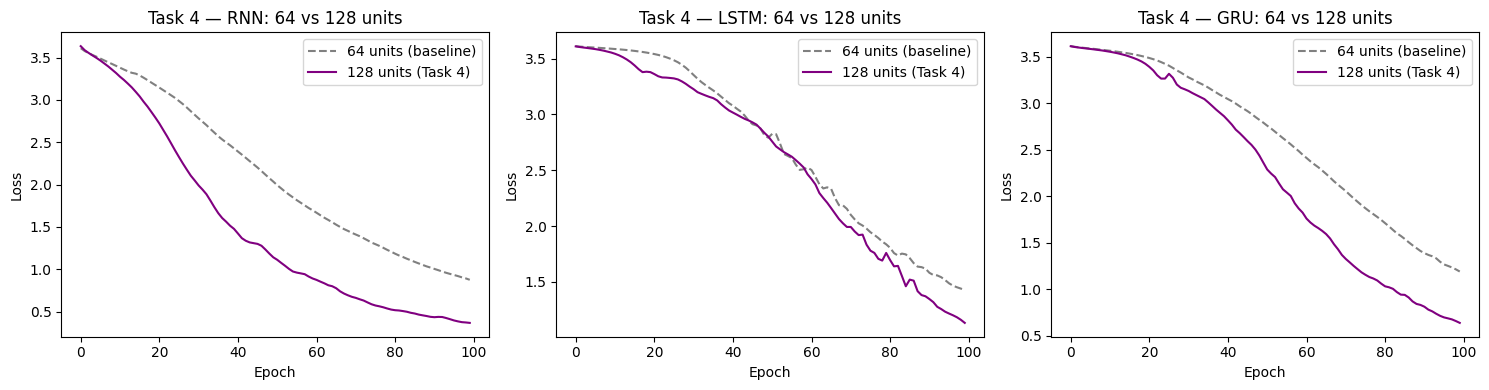


--- Task 4: Generated text with 128-unit models ---
RNN-128 : deep learning models transforming generate meaningful sentences
LSTM-128: deep learning is can artificial intelligence sentences
GRU-128 : deep learning models can generate meaningful sentences


In [13]:
# ── Task 4: Hidden units 64 → 128 ─────────────────────────────────────────
rnn_128 = Sequential([
    Embedding(total_words, 32, input_length=max_len - 1),
    SimpleRNN(128),   # ← doubled
    Dense(total_words, activation="softmax")
])
rnn_128.compile(loss="sparse_categorical_crossentropy", optimizer="adam", metrics=["accuracy"])
h_rnn_128 = rnn_128.fit(X, y, epochs=100, verbose=0)
print("RNN-128  done | final loss:", round(h_rnn_128.history["loss"][-1], 4))

lstm_128 = Sequential([
    Embedding(total_words, 32, input_length=max_len - 1),
    LSTM(128),        # ← doubled
    Dense(total_words, activation="softmax")
])
lstm_128.compile(loss="sparse_categorical_crossentropy", optimizer="adam", metrics=["accuracy"])
h_lstm_128 = lstm_128.fit(X, y, epochs=100, verbose=0)
print("LSTM-128 done | final loss:", round(h_lstm_128.history["loss"][-1], 4))

gru_128 = Sequential([
    Embedding(total_words, 32, input_length=max_len - 1),
    GRU(128),         # ← doubled
    Dense(total_words, activation="softmax")
])
gru_128.compile(loss="sparse_categorical_crossentropy", optimizer="adam", metrics=["accuracy"])
h_gru_128 = gru_128.fit(X, y, epochs=100, verbose=0)
print("GRU-128  done | final loss:", round(h_gru_128.history["loss"][-1], 4))

# Plot: 64 units vs 128 units for all three models
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
pairs = [
    (axes[0], rnn_history.history["loss"],   h_rnn_128.history["loss"],  "RNN"),
    (axes[1], lstm_history.history["loss"],  h_lstm_128.history["loss"], "LSTM"),
    (axes[2], gru_history.history["loss"],   h_gru_128.history["loss"],  "GRU"),
]
for ax, h64, h128, title in pairs:
    ax.plot(h64,  label="64 units (baseline)", linestyle="--", color="gray")
    ax.plot(h128, label="128 units (Task 4)",  linestyle="-",  color="purple")
    ax.set_title(f"Task 4 — {title}: 64 vs 128 units")
    ax.set_xlabel("Epoch"); ax.set_ylabel("Loss"); ax.legend()

plt.tight_layout(); plt.show()

print("\n--- Task 4: Generated text with 128-unit models ---")
print("RNN-128 :", generate_text(rnn_128,  "deep learning", 5))
print("LSTM-128:", generate_text(lstm_128, "deep learning", 5))
print("GRU-128 :", generate_text(gru_128,  "deep learning", 5))

## ✅ Task 5 — Generate 10 Words Instead of 5

Increasing the generation length from 5 to 10 words tests the model's ability to maintain
coherent multi-step predictions. Each prediction feeds into the next, so errors compound —
this is where LSTM and GRU's memory advantages become most visible.

In [14]:
# ── Task 5: Generate 10-word sequences ─────────────────────────────────────
NEXT_WORDS = 10

seeds = ["deep learning", "recurrent neural", "lstm helps", "text generation"]

print("=" * 65)
print(f"Task 5 — Generating {NEXT_WORDS}-word sequences from 4 seed phrases")
print("=" * 65)

for seed in seeds:
    rnn_out  = generate_text(rnn_model,  seed, NEXT_WORDS)
    lstm_out = generate_text(lstm_model, seed, NEXT_WORDS)
    gru_out  = generate_text(gru_model,  seed, NEXT_WORDS)
    print(f"\nSeed: \"{seed}\"")
    print(f"  RNN  → {rnn_out}")
    print(f"  LSTM → {lstm_out}")
    print(f"  GRU  → {gru_out}")

# Final summary: compare all models at 10-word generation
print("\n" + "=" * 65)
print("TASK 5 — Summary: 10-word output from \"deep learning\"")
print("=" * 65)
summary_rows = []
for name, model in [("RNN Baseline", rnn_model), ("LSTM Baseline", lstm_model),
                    ("GRU Baseline", gru_model), ("GRU 200ep (T3)", gru_200),
                    ("GRU 128-units (T4)", gru_128)]:
    out = generate_text(model, "deep learning", NEXT_WORDS)
    summary_rows.append({"Model": name, "Generated Text": out})
    print(f"  {name:<20}: {out}")

import pandas as pd
pd.DataFrame(summary_rows)

Task 5 — Generating 10-word sequences from 4 seed phrases

Seed: "deep learning"
  RNN  → deep learning models transforming artificial intelligence sentences intelligence word simpler sentences data
  LSTM → deep learning is artificial artificial intelligence intelligence intelligence lstm lstm lstm dependencies
  GRU  → deep learning models can generate meaningful meaningful sentences sentences sentences lstm sequential

Seed: "recurrent neural"
  RNN  → recurrent neural is are useful for sequential data generate data sentences data
  LSTM → recurrent neural neural networks for for sequential sequential sequential data sequential sequential
  GRU  → recurrent neural networks are useful for sequential data data data data data

Seed: "lstm helps"
  RNN  → lstm helps remember long term dependencies word sequential data models data artificial
  LSTM → lstm helps neural long dependencies dependencies dependencies sequential sequential data sequential sequential
  GRU  → lstm helps remember

,Model,Generated Text
0,RNN Baseline,deep learning models transforming artificial i...
1,LSTM Baseline,deep learning is artificial artificial intelli...
2,GRU Baseline,deep learning models can generate meaningful m...
3,GRU 200ep (T3),deep learning models can generate meaningful s...
4,GRU 128-units (T4),deep learning models can generate meaningful s...


# ✅ Conclusion
- **Vanilla RNN** learns short patterns but struggles with memory
- **LSTM** captures long-range grammar dependencies better
- **GRU** gives similar performance with fewer gates and faster training
- This notebook helps students understand **sequence modeling mathematically and practically**